# Ground-Truth Evaluation with the CERT r4.1 Answer Key

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import StratifiedKFold, cross_val_predict

In [3]:
pd.set_option('display.max_columns', 60)
sns.set_theme(style='whitegrid', context='notebook')
plt.rcParams['figure.dpi'] = 110
# ART_DIR = Path('../artifacts'); ANS_DIR = Path('../answers')
ART_DIR = Path('/content/drive/MyDrive/artifacts')
ANS_DIR = Path('/content/drive/MyDrive/answers')
np.random.seed(42)

## The official answer key

insiders.csv is the master list of true positives across every CERT release: it names the dataset, the red-team scenario number, the detail file, the offending user, and the start/end of the malicious window. We filter to release 4.1 — the dataset this project uses.

In [4]:
key = pd.read_csv(ANS_DIR / 'insiders.csv', dtype=str)
r41 = key[key['dataset'] == '4.1'].reset_index(drop=True)
r41

,dataset,scenario,details,user,start,end
0,4.1,1,r4.1-1.csv,ABB0427,08/21/2010 05:20:34,08/27/2010 05:39:51
1,4.1,2,r4.1-2.csv,HFC0492,08/23/2010 10:40:56,10/14/2010 17:11:42
2,4.1,3,r4.1-3.csv,KTW0365,07/08/2010 11:51:00,07/09/2010 20:54:16


r4.1 contains three insiders — one enacting each of scenarios 1, 2 and 3 — not the “two instances” the data-release README loosely mentions. The answer key is authoritative, so the ground truth for this project is exactly ABB0427, HFC0492 and KTW0365.

## What each insider did
From the answer key's scenarios.txt, mapped to the three r4.1 users:

- **ABB0427 — scenario 1:** a user who never worked after hours or used removable drives suddenly logs in after hours, connects a thumb drive, and uploads data to wikileaks.org, then leaves the organisation.
- **HFC0492 — scenario 2:** a user starts browsing job sites and courting a competitor, then — shortly before resigning — uses a thumb drive at a markedly higher rate than usual to steal data.
- **KTW0365 — scenario 3:** a disgruntled system administrator downloads a keylogger, plants it on a supervisor's machine, and sends an alarming mass email as that supervisor.

In [5]:
insiders = r41['user'].tolist()
periods = {row.user: (row.start, row.end) for row in r41.itertuples()}
insiders

['ABB0427', 'HFC0492', 'KTW0365']

## Attach ground-truth labels to the user table

We reload the engineered feature matrix and the labelled table from earlier notebooks and mark the three answer-key users as the only true positives.

In [6]:
fe = pd.read_parquet(ART_DIR / 'cert_engineered_features.parquet')
lab = pd.read_parquet(ART_DIR / 'cert_dataset_with_anomaly_labels.parquet')
fe.shape, lab.shape

((1000, 35), (1000, 29))

In [7]:
fe['insider'] = fe['user'].isin(insiders).astype(int)
int(fe['insider'].sum()), len(fe), round(fe['insider'].mean() * 100, 2)

(3, 1000, np.float64(0.3))

In [8]:
present = [u for u in insiders if u in set(fe['user'])]
assert len(present) == len(insiders), 'an answer-key insider is missing from the feature table'
present

['ABB0427', 'HFC0492', 'KTW0365']

All three insiders are present, giving a true base rate of 0.3% (3 in 1,000) — roughly thirty times rarer than the 9% proxy rate the supervised notebooks optimised against. The real task is extreme rare-event detection, and any metric quoted earlier against the 90-user proxy must be re-read in that light.

## How well did the proxy labels find the real insiders?

Before ranking anything, the blunt question: of the four unsupervised flags produced in Notebook 03, how many of the three genuine insiders does each actually catch, and at what false-positive cost?

In [9]:
detectors = ['iso_anomaly', 'lof_anomaly', 'consensus_strict', 'consensus_loose']
truth = set(insiders)
rows = []
for c in detectors:
    flagged = set(lab.loc[lab[c] == 1, 'user'])
    caught = len(truth & flagged)
    rows.append({'detector': c, 'users_flagged': len(flagged),
                 'insiders_caught': caught, 'insiders_missed': len(truth) - caught})
proxy_vs_truth = pd.DataFrame(rows)
proxy_vs_truth

,detector,users_flagged,insiders_caught,insiders_missed
0,iso_anomaly,50,0,3
1,lof_anomaly,50,1,2
2,consensus_strict,10,0,3
3,consensus_loose,90,1,2


The proxy is not a proxy for truth. consensus_loose raises 90 alerts yet recovers only one of the three insiders; consensus_strict and Isolation Forest recover none. The unsupervised ensemble captures generic statistical outliers — overwhelmingly benign — while missing two of the three real attackers. Training a classifier to reproduce this label therefore teaches it the wrong target.

## Rare-event ranking metrics

With only three positives, a train/test AUC is noise. The operational question is instead: if an analyst reviews the top-k highest-risk users, how many insiders surface? We measure recall@k and the explicit rank of each insider. For the continuous detector scores, more-negative Isolation-Forest / LOF values are more anomalous (ascending rank), whereas a higher engineered activity_anomaly_score is more anomalous (descending rank).

In [10]:
def ranks(series, ascending):
    r = series.rank(ascending=ascending, method='min')
    return {u: int(r[u]) for u in insiders}

def recall_at_k(series, ascending, ks=(10, 20, 50, 100)):
    r = series.rank(ascending=ascending, method='min')
    hit = {u: int(r[u]) for u in insiders}
    return {k: int(sum(v <= k for v in hit.values())) for k in ks}

In [11]:
scores = lab.set_index('user')[['iso_score', 'lof_score']].copy()
scores['activity_anomaly_score'] = fe.set_index('user')['activity_anomaly_score']
scores.loc[insiders]

,iso_score,lof_score,activity_anomaly_score
user,,,
ABB0427,-0.554707,-1.116879,0.495035
HFC0492,-0.487562,-0.994780,0.027379
KTW0365,-0.561271,-1.576526,0.247257


## A proxy-trained model, scored against truth

Notebooks 04–06 trained supervised models to reproduce consensus_loose. To test whether imitating the proxy also surfaces real insiders, we take a RandomForest, generate out-of-fold probabilities across all 1,000 users (trained only on the proxy label), and rank users by them — then score that ranking against the answer key.

In [12]:
feats = json.load(open(ART_DIR / 'model_feature_list.json'))
X = fe[feats].fillna(0).values
y_proxy = fe['consensus_loose'].astype(int).values
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
rf = RandomForestClassifier(n_estimators=200, class_weight='balanced', random_state=42)
oof = cross_val_predict(rf, X, y_proxy, cv=cv, method='predict_proba')[:, 1]
scores['rf_proxy_proba'] = pd.Series(oof, index=fe['user'].values)
scores.loc[insiders, 'rf_proxy_proba']

,rf_proxy_proba
user,
ABB0427,0.160
HFC0492,0.045
KTW0365,0.195


## Recall@k across score sources

In [13]:
directions = {'iso_score': True, 'lof_score': True,
              'activity_anomaly_score': False, 'rf_proxy_proba': False}
recall_tbl = pd.DataFrame({c: recall_at_k(scores[c], asc)
                           for c, asc in directions.items()}).T
recall_tbl.columns = [f'recall@{k}' for k in recall_tbl.columns]
recall_tbl

,recall@10,recall@20,recall@50,recall@100
iso_score,0,0,0,2
lof_score,0,1,1,1
activity_anomaly_score,2,2,2,2
rf_proxy_proba,0,0,0,0


In [14]:
rank_tbl = pd.DataFrame({c: ranks(scores[c], asc) for c, asc in directions.items()})
rank_tbl.index.name = 'insider'
rank_tbl

,iso_score,lof_score,activity_anomaly_score,rf_proxy_proba
insider,,,,
ABB0427,84,183,1,137
HFC0492,203,804,341,295
KTW0365,72,11,10,113


The engineered activity_anomaly_score is the strongest single detector — it lands two of the three insiders in the top 10. Isolation Forest needs the top 100 to reach two, and LOF recovers just one.

## Where the insiders rank

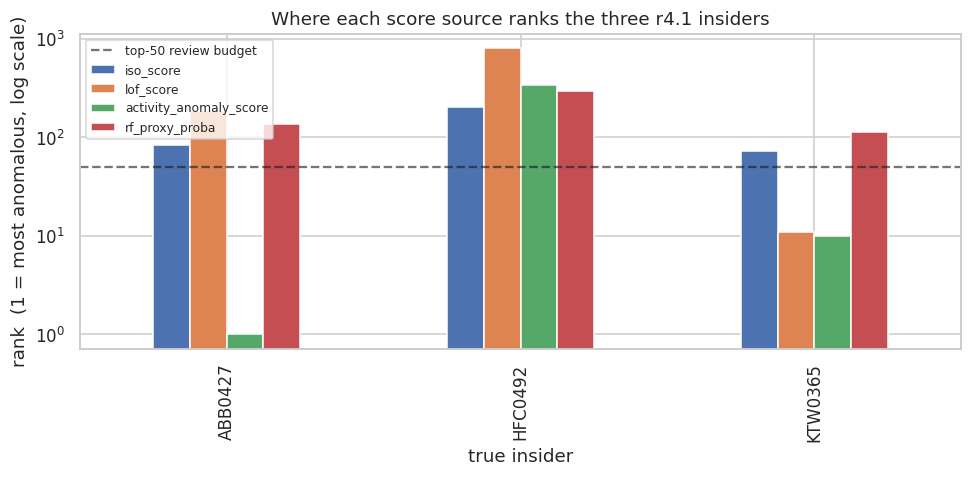

In [15]:
fig, ax = plt.subplots(figsize=(9, 4.5))
rank_tbl.plot(kind='bar', ax=ax, logy=True)
ax.axhline(50, color='k', ls='--', alpha=0.6, label='top-50 review budget')
ax.set_ylabel('rank  (1 = most anomalous, log scale)')
ax.set_xlabel('true insider')
ax.set_title('Where each score source ranks the three r4.1 insiders')
ax.legend(loc='upper left', fontsize=8)
plt.tight_layout()
plt.show()

## Per-insider case study

Comparing each insider's behavioural aggregates against the population median shows *why* the ranking behaves as it does.

In [16]:
profile_cols = ['after_hours_logons', 'after_hours_device', 'after_hours_files',
                'device_intensity', 'file_intensity', 'activity_anomaly_score']
case = fe.set_index('user').loc[insiders, profile_cols].T
case['pop_median'] = fe[profile_cols].median().values
case

user,ABB0427,HFC0492,KTW0365,pop_median
after_hours_logons,10.000000,55.000000,611.000000,0.0
after_hours_device,34.000000,12.000000,2.000000,0.0
after_hours_files,41.000000,3.000000,0.000000,0.0
device_intensity,0.093151,2.391781,0.010959,0.0
file_intensity,0.112329,1.073973,0.002740,0.0
activity_anomaly_score,0.495035,0.027379,0.247257,0.0


ABB0427 is behaviourally loud — after-hours logons, device use and file activity all spike far above the median, so aggregate scores flag it immediately. KTW0365 is moderately elevated. HFC0492 sits close to the median on every aggregate: its data theft is a brief, late-stage burst that averages away over the 17-month window, which is why only per-day / sequential modelling can hope to catch it.

In [17]:
gt = fe[['user', 'insider']].copy()
meta = r41.set_index('user')
gt['scenario'] = gt['user'].map(meta['scenario']).fillna('')
gt['start'] = gt['user'].map(meta['start']).fillna('')
gt['end'] = gt['user'].map(meta['end']).fillna('')
out = ART_DIR / 'cert_ground_truth_labels.csv'
gt.to_csv(out, index=False)
gt[gt['insider'] == 1]

,user,insider,scenario,start,end
137,ABB0427,1,1,08/21/2010 05:20:34,08/27/2010 05:39:51
300,KTW0365,1,3,07/08/2010 11:51:00,07/09/2010 20:54:16
312,HFC0492,1,2,08/23/2010 10:40:56,10/14/2010 17:11:42
